<a href="https://colab.research.google.com/github/anagaglory/iris-kmeans-clustering-analysis/blob/main/Cluster_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

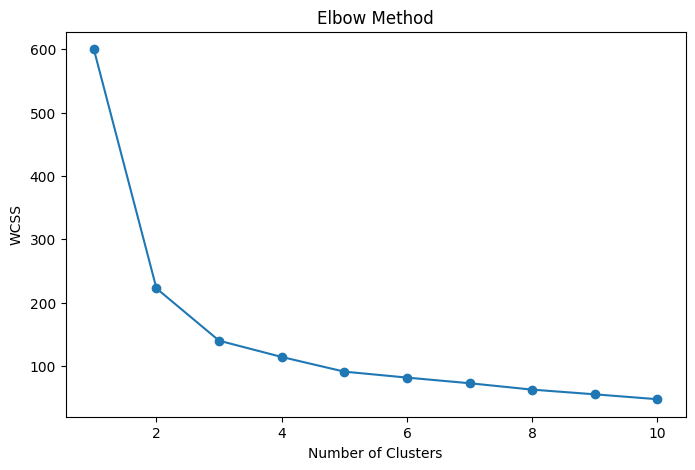

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [ ]:
plt.savefig('elbow_method.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

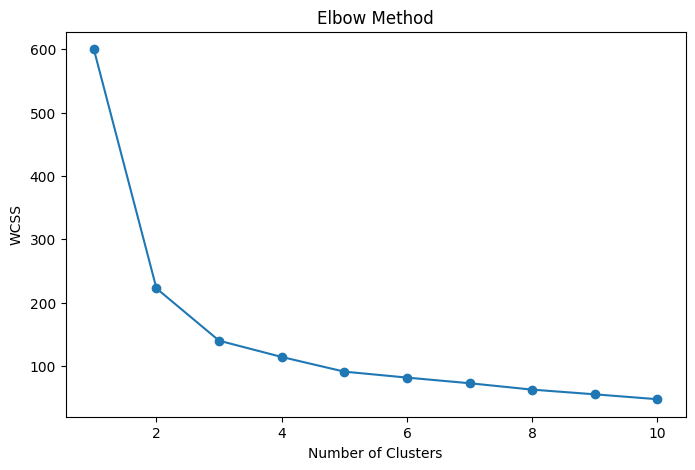

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.savefig('elbow_method.png', bbox_inches='tight')  # Save first
plt.show()                                           # Then display

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

In [ ]:
df['Cluster'] = clusters

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


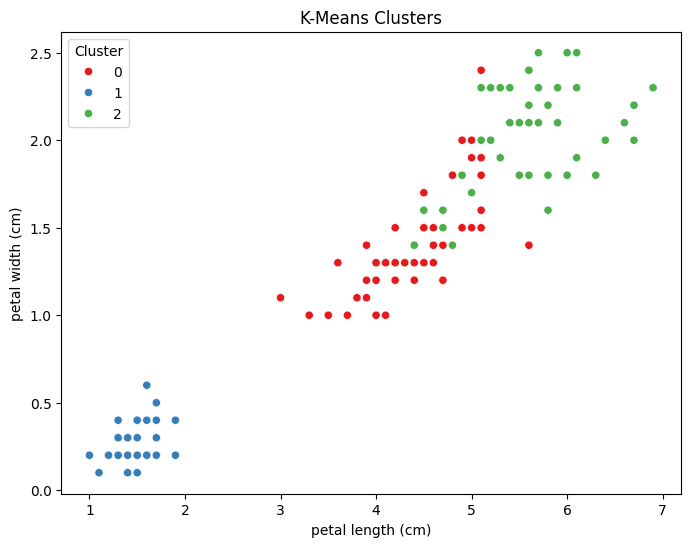

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title('K-Means Clusters')

plt.show()

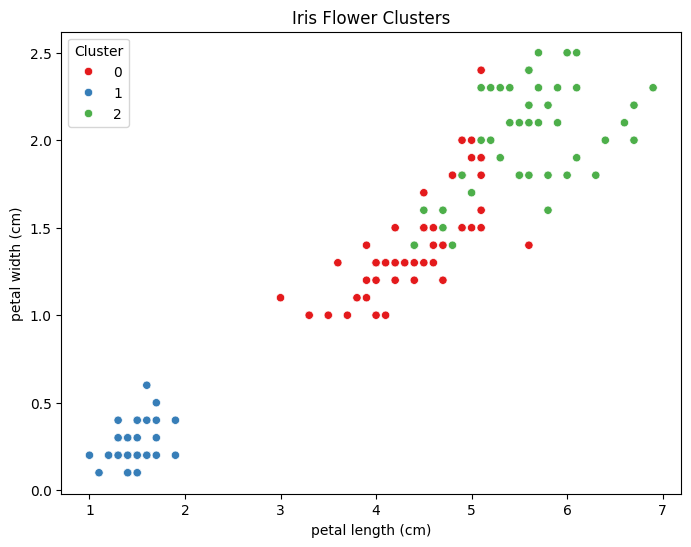

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='Cluster',
    palette='Set1'
)

plt.title('Iris Flower Clusters')

plt.savefig('iris_clusters.png', bbox_inches='tight')  # Save first
plt.show()